In [2]:
import torch
import torch.nn.functional as F
import random
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from scipy.interpolate import CubicSpline
class SubAnomaly(object):
    def __init__(self, jitter_ratio=0.02, scaling_ratio=0.1, max_segments=5, 
                 frequency_mask_ratio=0.1, frequency_add_ratio=0.1):
        self.jitter_ratio = jitter_ratio
        self.scaling_ratio = scaling_ratio
        self.max_segments = max_segments
        self.frequency_mask_ratio = frequency_mask_ratio
        self.frequency_add_ratio = frequency_add_ratio
    def jitter(self, x, sigma):
        noise = torch.randn_like(x) * sigma
        return x + noise
    def scaling(self, x, sigma):
        factor = torch.randn(x.shape[0], 1, 1, device=x.device) * sigma + 1.0
        return x * factor
    def one_hot_encoding(self, X, num_classes):
        return F.one_hot(X, num_classes=num_classes).float()
    def permutation(self, x, max_segments):
        B, T, D = x.shape
        ret = torch.zeros_like(x)
        for i in range(B):
            num_segs = torch.randint(1, max_segments + 1, (1,)).item()
            if num_segs > 1:
 
                split_points = torch.sort(torch.randperm(T - 2)[:num_segs - 1]).values
                split_points = split_points.cpu().numpy().tolist()
 
                split_sizes = [split_points[0]]
                for j in range(1, len(split_points)):
                    split_sizes.append(split_points[j] - split_points[j - 1])
                split_sizes.append(T - split_points[-1])
 
                splits = torch.split(torch.arange(T, device=x.device), split_sizes)
                splits = list(splits)
                random.shuffle(splits)
                warp = torch.cat(splits)
 
                ret[i] = x[i, warp, :]
            else:
                ret[i] = x[i]
        return ret

    def remove_frequency(self, x, maskout_ratio=0.1):
        freq = torch.fft.fft(x, dim=1)
        mask = torch.rand(freq.shape, device=x.device) > maskout_ratio
        freq_masked = freq * mask
        x_masked = torch.fft.ifft(freq_masked, dim=1).real
        return x_masked

    def add_frequency(self, x, pertub_ratio=0.1):
        freq = torch.fft.fft(x, dim=1)
        mask = torch.rand(freq.shape, device=x.device) > (1 - pertub_ratio)
        random_phase = torch.rand(freq.shape, device=x.device) * 2 * torch.pi
        random_amplitude = torch.rand(freq.shape, device=x.device) * 0.1 * torch.abs(freq)
        freq_perturbed = mask * random_amplitude * torch.exp(1j * random_phase)
        freq_new = freq + freq_perturbed
        x_perturbed = torch.fft.ifft(freq_new, dim=1).real
        return x_perturbed
    def DataTransform_TD(self, sample):
        aug_1 = self.jitter(sample, sigma=self.jitter_ratio)
        aug_2 = self.scaling(sample, sigma=self.scaling_ratio)
        aug_3 = self.permutation(sample, max_segments=self.max_segments)

        aug_stack = torch.stack([aug_1, aug_2, aug_3], dim=1) 
        li = torch.randint(0, 3, (sample.shape[0],), device=sample.device) 
        li_onehot = self.one_hot_encoding(li, num_classes=3) 

        li_onehot = li_onehot.unsqueeze(-1).unsqueeze(-1) 
        li_onehot = li_onehot.expand(-1, -1, sample.size(1), sample.size(2)) 

        aug_T = (aug_stack * li_onehot).sum(dim=1) 
        assert aug_T.shape == sample.shape, f"Augmented signal shape {aug_T.shape} does not match original {sample.shape}"

        return aug_T

    def DataTransform_FD(self, sample):
        aug_1 = self.remove_frequency(sample, maskout_ratio=self.frequency_mask_ratio)
        aug_2 = self.add_frequency(sample, pertub_ratio=self.frequency_add_ratio)

        aug_stack = torch.stack([aug_1, aug_2], dim=1) 
        li = torch.randint(0, 2, (sample.shape[0],), device=sample.device) 
        li_onehot = self.one_hot_encoding(li, num_classes=2) 

        li_onehot = li_onehot.unsqueeze(-1).unsqueeze(-1) 
        li_onehot = li_onehot.expand(-1, -1, sample.size(1), sample.size(2)) 

        aug_F = (aug_stack * li_onehot).sum(dim=1) 
        assert aug_F.shape == sample.shape, f"Augmented signal shape {aug_F.shape} does not match original {sample.shape}"
        return aug_F

    def __call__(self, x):

        view1 = self.DataTransform_TD(x)
        view2 = self.DataTransform_FD(x)
        return view1, view2

def time_warp_s(x, sigma=0.05, knot=2, plot=False):
    from scipy.interpolate import CubicSpline
    orig_steps = np.arange(x.shape[0])

    random_warps = np.random.normal(loc=1.0, scale=sigma, size=(1, knot + 2, x.shape[1]))
    warp_steps = (np.ones((x.shape[1], 1)) * (np.linspace(0, x.shape[0] - 1., num=knot + 2))).T

    ret = np.zeros_like(x)
    for dim in range(x.shape[1]):
        time_warp = CubicSpline(warp_steps[:, dim], warp_steps[:, dim] * random_warps[0, :, dim])(orig_steps)
        scale = (x.shape[0] - 1) / time_warp[-1]
        ret[:, dim] = np.interp(orig_steps, np.clip(scale * time_warp, 0, x.shape[0] - 1), x[:, dim]).T
    return ret
def magnitude_warp_s(x, sigma=0.05, knot=2, plot=False):
    from scipy.interpolate import CubicSpline
    orig_steps = np.arange(x.shape[0])

 
    if not isinstance(x, np.ndarray):
        x = np.array(x, dtype=np.float32)

 
    random_warps = np.random.normal(loc=1.0, scale=sigma, size=(1, knot + 2, x.shape[1]))
    warp_steps = (np.ones((x.shape[1], 1)) * (np.linspace(0, x.shape[0] - 1., num=knot + 2))).T

    li = []
    for dim in range(x.shape[1]):
        li.append(CubicSpline(warp_steps[:, dim], random_warps[0, :, dim])(orig_steps))
    warper = np.array(li).T

 
    if not isinstance(warper, np.ndarray):
        warper = np.array(warper, dtype=np.float32)

 
    x_ = x * warper
    return x_
def DataTransform_SemiTime(sample):
    if isinstance(sample, torch.Tensor):
        sample = sample.detach().cpu().numpy()

    t1 = time_warp_s(magnitude_warp_s(sample))
 
 
 
    sample = np.array(sample,dtype=np.float64)
    return t1,sample


In [3]:
import numpy as np
unmoda = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.unmod.a.tsv"
m6a = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.m6a.tsv"
m1a = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.m1a.tsv"

kmer_encode_dic={'A': 0, "C": 1, "G": 2, "T": 3}
def load_predict_data(file, max_length=500, signal_length=500):
    X, signals = [], []
    count = 0
    with open(file) as f:
        for line in f:
            line = line.rstrip()
            items = line.split("\t")

 
            raw_signals = "|".join(items[9:14]).split("|")
            signal = np.array([float(s) for s in raw_signals])

 
 

 
            if len(signal) < signal_length:
                signal = np.pad(signal, (0, signal_length - len(signal)), mode='constant')
            else:
                signal = signal[:signal_length]

 
            kmer = items[3]
            kmer = np.array([kmer_encode_dic[base] for base in kmer]) 
            mean = np.array([float(item) for item in items[4].split("|")]) 
            std = np.array([float(item) for item in items[5].split("|")]) 
            intense = np.array([float(item) for item in items[6].split("|")]) 
            dwell = np.array([float(item) for item in items[7].split("|")]) / 200 
            base_quality = np.array([float(item) for item in items[8].split("|")]) / 40 

 
            x = np.hstack([kmer, mean, std, intense, dwell, base_quality]) 

            X.append(x)
            signals.append(signal)
            count += 1
            if count >= max_length:
                break

    return np.array(X), np.array(signals) 


datasets = {
    "normalA": unmoda,
    "m6a": m6a,    
    "m1a": m1a,
}
x_list, y_list, signal_list = [], [], []

for label, path in datasets.items():
    data, signals = load_predict_data(path, max_length=100, signal_length=500)
    print(f"{label} data shape: {data.shape}, signals shape: {signals.shape}")
    
    x_list.append(data)
    signal_list.append(signals)
    y_list.extend([label] * len(data))


x = np.vstack(x_list) 
signal = np.vstack(signal_list) 
y = np.array(y_list) 


print("Final shapes:")
print("x:", x.shape) 
print("y:", y.shape) 
print("signal:", signal.shape) 

normalA data shape: (100, 30), signals shape: (100, 500)
m6a data shape: (100, 30), signals shape: (100, 500)
m1a data shape: (100, 30), signals shape: (100, 500)
Final shapes:
x: (300, 30)
y: (300,)
signal: (300, 500)


(500,)
✅ 数据已保存至 signal_augmentation.csv，可以在 Origin 中导入并作图！


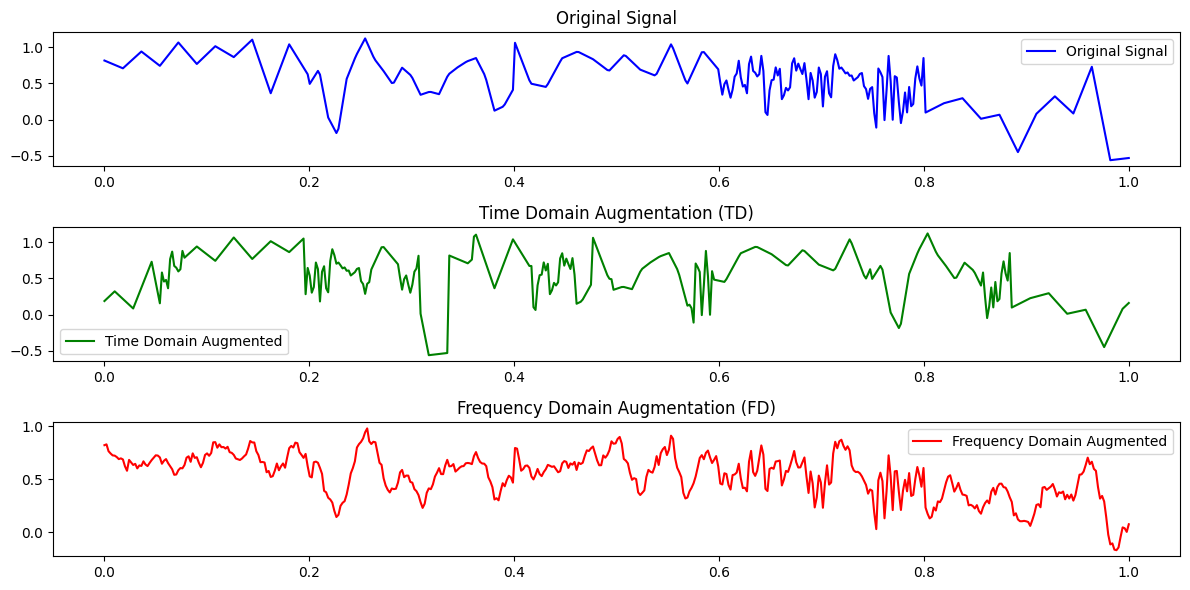

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
print(signal[6].shape)
original_signal = signal[0].reshape(1, 500, 1) 

original_tensor = torch.tensor(original_signal, dtype=torch.float32)
time_axis = np.linspace(0, 1, 500)


augmentor = SubAnomaly(jitter_ratio=0.05, scaling_ratio=0.3, max_segments=20, 
                        frequency_mask_ratio=0.5, frequency_add_ratio=0.2)

td_augmented, fd_augmented = augmentor(original_tensor)
# 转换回 NumPy
td_augmented = td_augmented.squeeze().detach().numpy()
fd_augmented = fd_augmented.squeeze().detach().numpy()
original_signal = original_signal.squeeze() 


df = pd.DataFrame({
    'Time': np.linspace(0, 1, 500),
    'Original Signal': original_signal,
    'Time Domain Augmented': td_augmented,
    'Frequency Domain Augmented': fd_augmented
})


csv_filename = "signal_augmentation.csv"
df.to_csv(csv_filename, index=False)

print(f"✅ 数据已保存至 {csv_filename}，可以在 Origin 中导入并作图！")

plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
plt.plot(time_axis, original_signal.squeeze(), label="Original Signal", color='b')
plt.title("Original Signal")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(time_axis, td_augmented, label="Time Domain Augmented", color='g')
plt.title("Time Domain Augmentation (TD)")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(time_axis, fd_augmented, label="Frequency Domain Augmented", color='r')
plt.title("Frequency Domain Augmentation (FD)")
plt.legend()
plt.tight_layout()
plt.show()

Original signal shape: (500,)
✅ 数据已保存至 semi_time_augmentation.csv，可以在 Origin 中导入并作图！


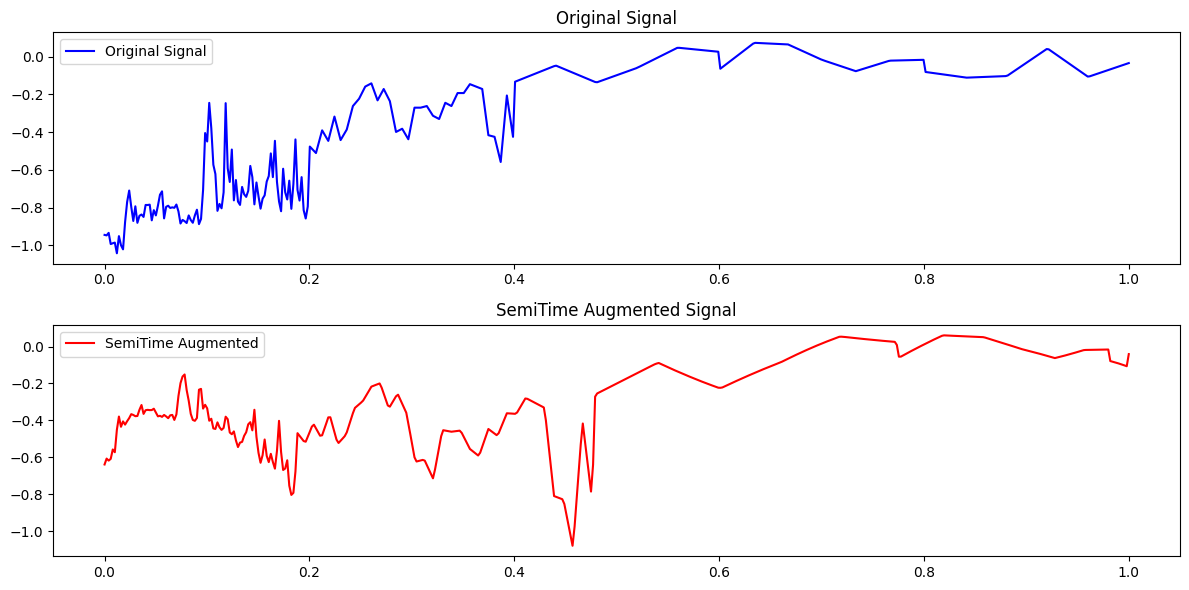

In [174]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
def time_warp_s(x, sigma=0.3, knot=2, plot=False):
    from scipy.interpolate import CubicSpline
    orig_steps = np.arange(x.shape[0])

    random_warps = np.random.normal(loc=1.0, scale=sigma, size=(1, knot + 2, x.shape[1]))
    warp_steps = (np.ones((x.shape[1], 1)) * (np.linspace(0, x.shape[0] - 1., num=knot + 2))).T

    ret = np.zeros_like(x)
    for dim in range(x.shape[1]):
        time_warp = CubicSpline(warp_steps[:, dim], warp_steps[:, dim] * random_warps[0, :, dim])(orig_steps)
        scale = (x.shape[0] - 1) / time_warp[-1]
        ret[:, dim] = np.interp(orig_steps, np.clip(scale * time_warp, 0, x.shape[0] - 1), x[:, dim]).T
    return ret
def magnitude_warp_s(x, sigma=0.4, knot=4, plot=False):
    from scipy.interpolate import CubicSpline
    orig_steps = np.arange(x.shape[0])

 
    if not isinstance(x, np.ndarray):
        x = np.array(x, dtype=np.float32)

 
    random_warps = np.random.normal(loc=1.0, scale=sigma, size=(1, knot + 2, x.shape[1]))
    warp_steps = (np.ones((x.shape[1], 1)) * (np.linspace(0, x.shape[0] - 1., num=knot + 2))).T

    li = []
    for dim in range(x.shape[1]):
        li.append(CubicSpline(warp_steps[:, dim], random_warps[0, :, dim])(orig_steps))
    warper = np.array(li).T

 
    if not isinstance(warper, np.ndarray):
        warper = np.array(warper, dtype=np.float32)

 
    x_ = x * warper
    return x_
def DataTransform_SemiTime(sample):
    if isinstance(sample, torch.Tensor):
        sample = sample.detach().cpu().numpy()

    t1 = time_warp_s(magnitude_warp_s(sample))
 
 
 
    sample = np.array(sample,dtype=np.float64)
    return t1,sample

time_axis = np.linspace(0, 1, 500)


print("Original signal shape:", signal[0].shape)

original_signal = signal[1].reshape(500, 1) 


semi_time_augmented, original_signal = DataTransform_SemiTime(original_signal)

df = pd.DataFrame({
    'Time': time_axis, 
    'Original Signal': original_signal.squeeze(), 
    'SemiTime Augmented': semi_time_augmented.squeeze() 
})


csv_filename = "semi_time_augmentation.csv"
df.to_csv(csv_filename, index=False)
print(f"✅ 数据已保存至 {csv_filename}，可以在 Origin 中导入并作图！")


plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(time_axis, original_signal.squeeze(), label="Original Signal", color='b')
plt.title("Original Signal")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(time_axis, semi_time_augmented.squeeze(), label="SemiTime Augmented", color='r')
plt.title("SemiTime Augmented Signal")
plt.legend()

plt.tight_layout()
plt.show()
